In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("../datasets/student_lifestyle_dataset.csv")

In [3]:
df.head()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student_ID                       2000 non-null   int64  
 1   Study_Hours_Per_Day              2000 non-null   float64
 2   Extracurricular_Hours_Per_Day    2000 non-null   float64
 3   Sleep_Hours_Per_Day              2000 non-null   float64
 4   Social_Hours_Per_Day             2000 non-null   float64
 5   Physical_Activity_Hours_Per_Day  2000 non-null   float64
 6   GPA                              2000 non-null   float64
 7   Stress_Level                     2000 non-null   object 
dtypes: float64(6), int64(1), object(1)
memory usage: 125.1+ KB


In [5]:
df.describe()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,1000.500000,7.475800,1.990100,7.501250,2.704550,4.32830,3.115960
std,577.494589,1.423888,1.155855,1.460949,1.688514,2.51411,0.298674
min,1.000000,5.000000,0.000000,5.000000,0.000000,0.00000,2.240000
25%,500.750000,6.300000,1.000000,6.200000,1.200000,2.40000,2.900000
50%,1000.500000,7.400000,2.000000,7.500000,2.600000,4.10000,3.110000
75%,1500.250000,8.700000,3.000000,8.800000,4.100000,6.10000,3.330000
max,2000.000000,10.000000,4.000000,10.000000,6.000000,13.00000,4.000000


In [6]:
df["Stress_Level"].value_counts()

Stress_Level
High        1029
Moderate     674
Low          297
Name: count, dtype: int64

In [7]:
sns.set_style("whitegrid")
sns.set_palette("GnBu_d")

C:\Users\cathe\AppData\Local\Temp\ipykernel_27352\315307221.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["GPA"], bins=30)


<Axes: xlabel='GPA', ylabel='Density'>

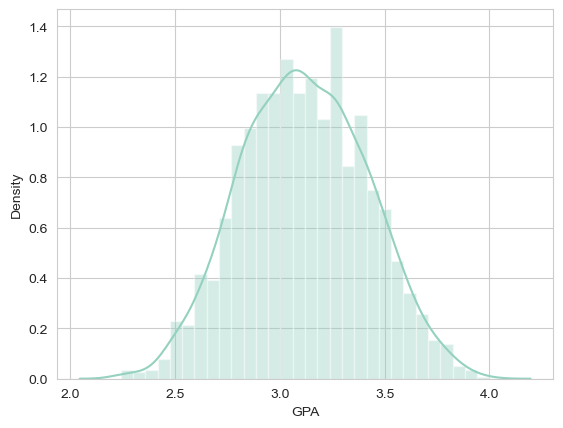

In [8]:
sns.distplot(df["GPA"], bins=30)

<Axes: xlabel='Stress_Level', ylabel='count'>

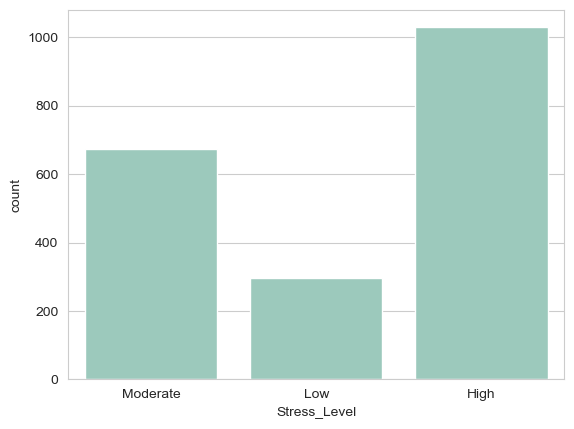

In [9]:
sns.countplot(x="Stress_Level", data=df)

In [10]:
df["Stress_Level"].unique()

array(['Moderate', 'Low', 'High'], dtype=object)

In [11]:
df["Stress_Level"] = df["Stress_Level"].replace({"Low": 0, "Moderate": 1, "High": 2})

C:\Users\cathe\AppData\Local\Temp\ipykernel_27352\756367829.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Stress_Level"] = df["Stress_Level"].replace({"Low": 0, "Moderate": 1, "High": 2})


In [12]:
df["Stress_Level"].head()

0    1
1    0
2    0
3    1
4    2
Name: Stress_Level, dtype: int64

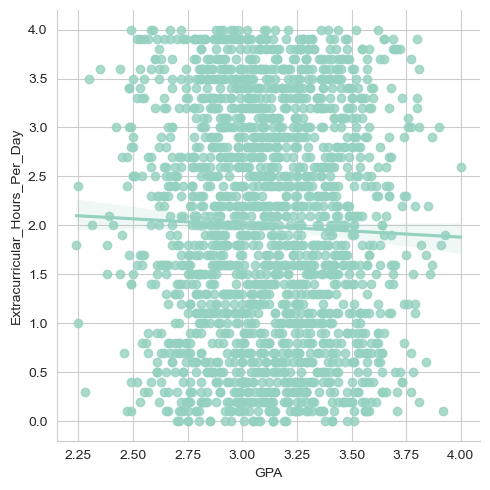

In [13]:
sns.lmplot(x="GPA", y="Extracurricular_Hours_Per_Day", data=df)

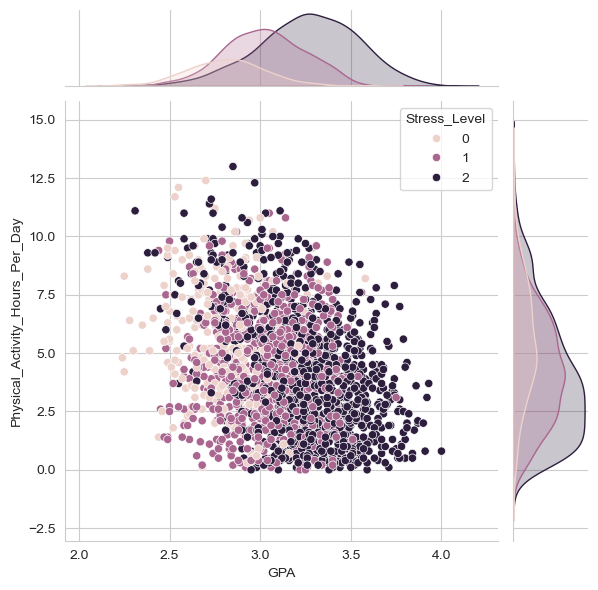

In [14]:
sns.jointplot(x="GPA", y="Physical_Activity_Hours_Per_Day", hue="Stress_Level", data=df)

<Axes: >

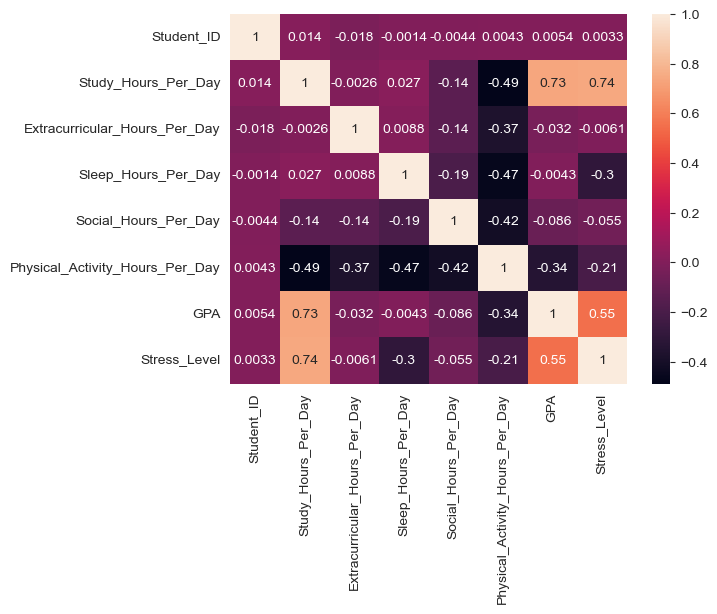

In [15]:
sns.heatmap(df.corr(), annot=True)

<Axes: xlabel='Stress_Level', ylabel='GPA'>

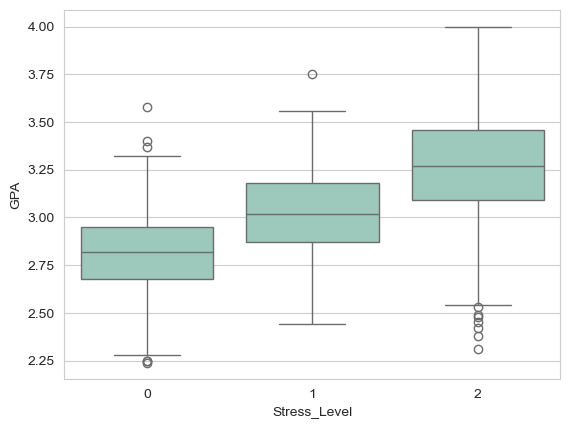

In [16]:
sns.boxplot(x="Stress_Level", y="GPA", data=df)

In [17]:
df.head()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,1,6.9,3.8,8.7,2.8,1.8,2.99,1
1,2,5.3,3.5,8.0,4.2,3.0,2.75,0
2,3,5.1,3.9,9.2,1.2,4.6,2.67,0
3,4,6.5,2.1,7.2,1.7,6.5,2.88,1
4,5,8.1,0.6,6.5,2.2,6.6,3.51,2


In [18]:
df.drop(["Student_ID"], axis=1, inplace=True)

In [19]:
df.head()

,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,6.9,3.8,8.7,2.8,1.8,2.99,1
1,5.3,3.5,8.0,4.2,3.0,2.75,0
2,5.1,3.9,9.2,1.2,4.6,2.67,0
3,6.5,2.1,7.2,1.7,6.5,2.88,1
4,8.1,0.6,6.5,2.2,6.6,3.51,2


#Standarize Data

In [20]:
from sklearn.preprocessing import StandardScaler

In [21]:
scaler = StandardScaler()
scaler.fit(df.drop("Stress_Level", axis=1))

StandardScaler()

In [22]:
knn_scaled = scaler.transform(df.drop("Stress_Level", axis=1))
knn_scaled

array([[-0.40448677,  1.56624592,  0.82073377,  0.05654313, -1.00589562,
        -0.42183684],
       [-1.52845139,  1.30663281,  0.34147317,  0.88588186, -0.52847018,
        -1.22559075],
       [-1.66894696,  1.65278363,  1.16306277, -0.89127256,  0.10809708,
        -1.49350872],
       ...,
       [-0.89622129, -1.72218687, -0.89091121, -1.12822648,  2.57479519,
         0.08050935],
       [ 0.4384867 , -1.11642293,  0.06760998,  0.47121249, -0.09083019,
        -0.25438811],
       [ 1.0707168 , -0.25104588, -0.13778742,  0.23425857, -0.56825563,
         1.55405818]])

In [26]:
df_features_scaled = pd.DataFrame(knn_scaled, columns=df.columns[:-1])

In [27]:
df_features_scaled.head()

,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA
0,-0.404487,1.566246,0.820734,0.056543,-1.005896,-0.421837
1,-1.528451,1.306633,0.341473,0.885882,-0.528470,-1.225591
2,-1.668947,1.652784,1.163063,-0.891273,0.108097,-1.493509
3,-0.685478,0.095105,-0.206253,-0.595080,0.864021,-0.790224
4,0.438487,-1.202961,-0.685514,-0.298888,0.903806,1.319630


In [29]:
X = df_features_scaled
y = df["Stress_Level"]

In [30]:
X

,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA
0,-0.404487,1.566246,0.820734,0.056543,-1.005896,-0.421837
1,-1.528451,1.306633,0.341473,0.885882,-0.528470,-1.225591
2,-1.668947,1.652784,1.163063,-0.891273,0.108097,-1.493509
3,-0.685478,0.095105,-0.206253,-0.595080,0.864021,-0.790224
4,0.438487,-1.202961,-0.685514,-0.298888,0.903806,1.319630
...,...,...,...,...,...,...
1995,-0.685478,-1.549111,-0.069322,-0.358126,1.381232,0.683325
1996,-0.825974,0.700869,0.889200,-0.713557,0.108097,-1.560488
1997,-0.896221,-1.722187,-0.890911,-1.128226,2.574795,0.080509
1998,0.438487,-1.116423,0.067610,0.471212,-0.090830,-0.254388


In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [32]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
error_rate = []
limit = 50

for i in range(1, limit):
    knn_test = KNeighborsClassifier(i)
    knn_test.fit(X_train, y_train)
    pred_y = knn_test.predict(X_test)
    error_rate.append(np.mean(pred_y != y_test))

Text(0.5, 1.0, 'Error rate with K values')

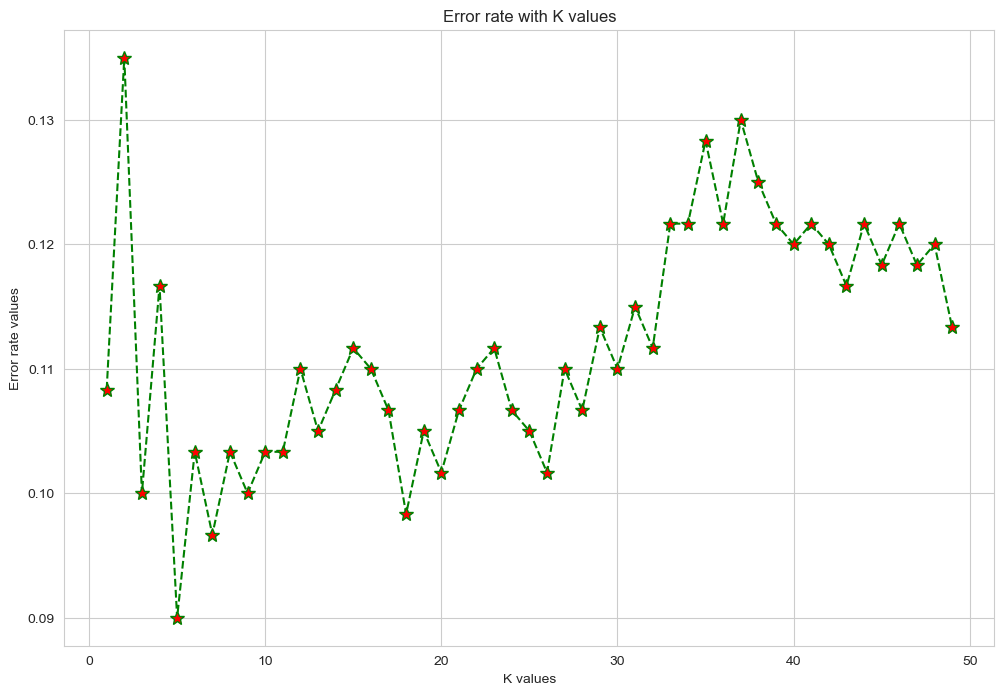

In [ ]:
plt.figure(figsize=(12,8))
plt.plot(range(1,limit), error_rate, color="green", ls="--", marker="*", markersize=10, markerfacecolor="red")
plt.xlabel("K values")
plt.ylabel("Error rate values")
plt.title("Error rate with K values")

In [35]:
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
K = 5
knn_eu = KNeighborsClassifier(K)
knn_eu.fit(X_train, y_train)
pred_eu = knn_eu.predict(X_test)

print(confusion_matrix(y_test, pred_eu))
print("---------------------------------")
print(classification_report(y_test, pred_eu))


[[ 83  10   3]
 [ 12 161  15]
 [  3  11 302]]
---------------------------------
              precision    recall  f1-score   support

           0       0.85      0.86      0.86        96
           1       0.88      0.86      0.87       188
           2       0.94      0.96      0.95       316

    accuracy                           0.91       600
   macro avg       0.89      0.89      0.89       600
weighted avg       0.91      0.91      0.91       600



Text(0.5, 1.0, 'Error rate with K values')

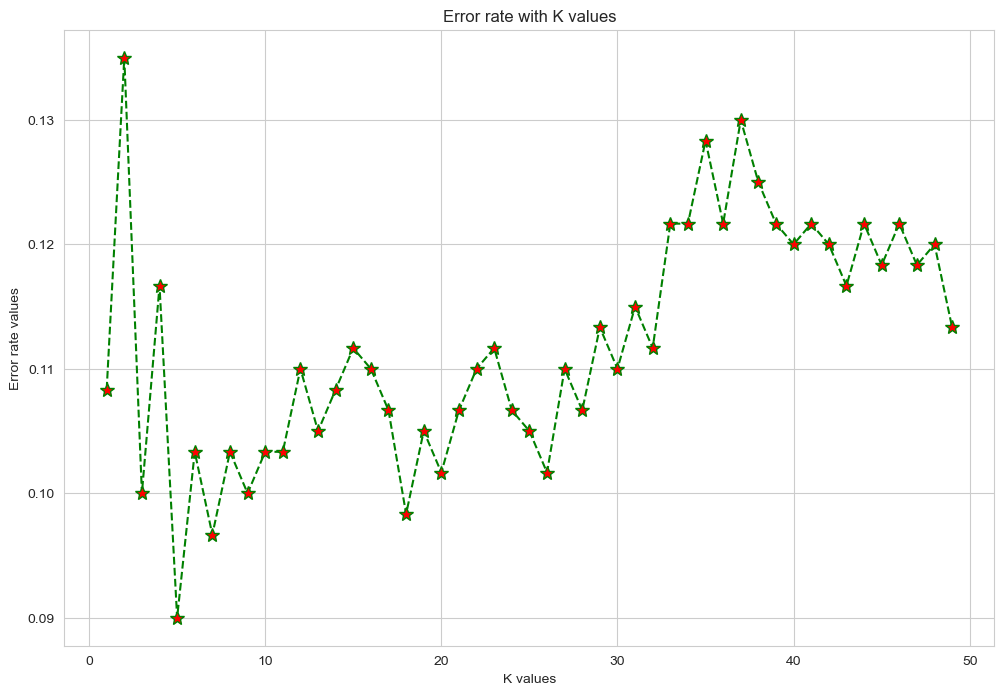

In [ ]:
error_rate_mink = []
limit = 50

for i in range(1, limit):
    knn_mink_test = KNeighborsClassifier(n_neighbors=i, metric="minkowski")
    knn_mink_test.fit(X_train, y_train)
    pred_y = knn_mink_test.predict(X_test)
    error_rate_mink.append(np.mean(pred_y != y_test))

plt.figure(figsize=(12,8))
plt.plot(range(1,limit), error_rate_mink, color="green", ls="--", marker="*", markersize=10, markerfacecolor="red")
plt.xlabel("K values")
plt.ylabel("Error rate values")
plt.title("Error rate with K values")

In [ ]:
K_MINK = 5
knn_mink = KNeighborsClassifier(n_neighbors=K_MINK, metric="minkowski")
knn_mink.fit(X_train, y_train)
pred_mink = knn_mink.predict(X_test)

print(confusion_matrix(y_test, pred_mink))
print("---------------------------------")
print(classification_report(y_test, pred_mink))

[[ 83  10   3]
 [ 12 161  15]
 [  3  11 302]]
---------------------------------
              precision    recall  f1-score   support

           0       0.85      0.86      0.86        96
           1       0.88      0.86      0.87       188
           2       0.94      0.96      0.95       316

    accuracy                           0.91       600
   macro avg       0.89      0.89      0.89       600
weighted avg       0.91      0.91      0.91       600



Text(0.5, 1.0, 'Error rate with K values')

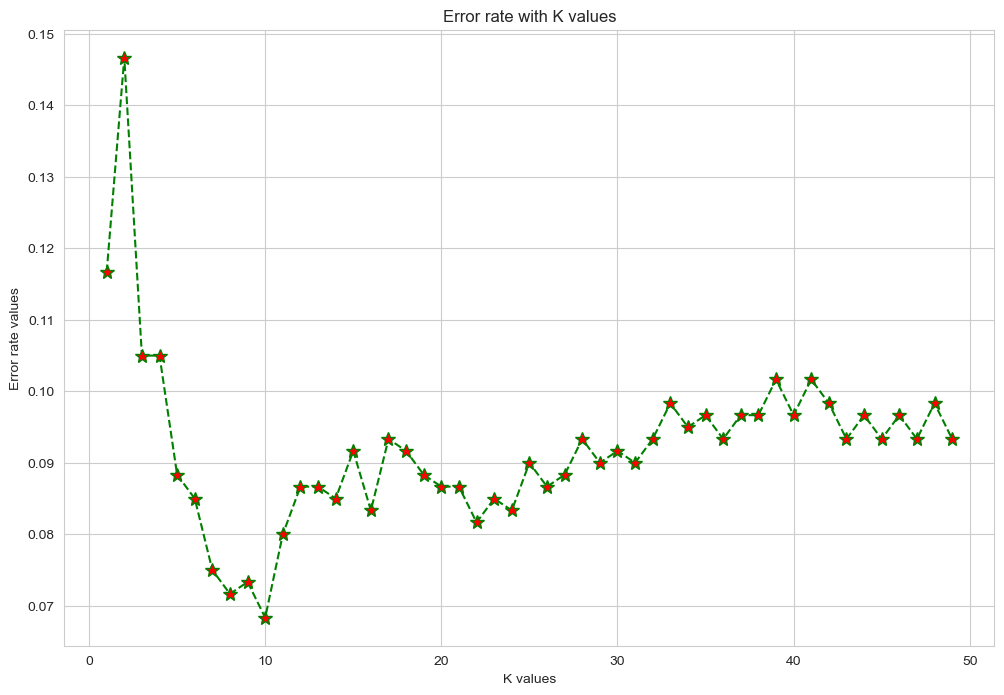

In [ ]:
error_rate_manh = []
limit = 50

for i in range(1, limit):
    knn_manh_test = KNeighborsClassifier(n_neighbors=i, metric="manhattan")
    knn_manh_test.fit(X_train, y_train)
    pred_y = knn_manh_test.predict(X_test)
    error_rate_manh.append(np.mean(pred_y != y_test))

plt.figure(figsize=(12,8))
plt.plot(range(1,limit), error_rate_manh, color="green", ls="--", marker="*", markersize=10, markerfacecolor="red")
plt.xlabel("K values")
plt.ylabel("Error rate values")
plt.title("Error rate with K values")

In [ ]:
K_MANH = 10
knn_manh = KNeighborsClassifier(n_neighbors=K_MANH, metric="manhattan")
knn_manh.fit(X_train, y_train)
pred_manh = knn_manh.predict(X_test)

print(confusion_matrix(y_test, pred_manh))
print("---------------------------------")
print(classification_report(y_test, pred_manh))

[[ 88   5   3]
 [  5 170  13]
 [  2  13 301]]
---------------------------------
              precision    recall  f1-score   support

           0       0.93      0.92      0.92        96
           1       0.90      0.90      0.90       188
           2       0.95      0.95      0.95       316

    accuracy                           0.93       600
   macro avg       0.93      0.92      0.93       600
weighted avg       0.93      0.93      0.93       600

